# 2-dimensional Simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import math

In [2]:
torch.manual_seed(23)

In [3]:
# Parameters
n = 50        # number of data points
d = 2         # dimension
device = 'cpu'

## Definition of datasets

In [4]:
# dataset 0: equidistant and not parallel
if n % 2 == 0: # avoids parallel points
  n = n+1
print('We cosider', n, 'datapoints.')
angles = torch.linspace(0, 2*np.pi, n+1)[:-1]
X_0 = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)
angles_0 = torch.atan2(X_0[:, 1], X_0[:, 0])
Y_0 = torch.sin(4*angles_0)

# dataset A: no parallelity
X_A = torch.randn(n, d, device=device)
normX_A = X_A / torch.norm(X_A, dim=1, keepdim=True)
angles_A = torch.atan2(normX_A[:, 1], normX_A[:, 0])
Y_A = torch.sin(4*angles_A)


# dataset B: includes some parallel vectors
mu = torch.zeros(d)
cov = torch.tensor([1.0, 3.0])

X_B = torch.normal(mu.repeat(n, 1), cov.repeat(n, 1))
normX_B = X_B / torch.norm(X_B, dim=1, keepdim=True)
angles_B = torch.atan2(normX_B[:, 1], normX_B[:, 0])
Y_B = torch.sin(4*angles_B)


# dataset C: dataset B with added parallel vectors
X_C = X_B
for i in range(round(n/2)):
  X_C = torch.cat([X_C, X_C[i].unsqueeze(0)])
normX_C = X_C / torch.norm(X_C, dim=1, keepdim=True)
angles_C = torch.atan2(normX_C[:, 1], normX_C[:, 0])
Y_C = torch.sin(4*angles_C)


# dataset D: lots of parallel vectors
mu_2 = torch.zeros(d)
cov_2 = torch.tensor([1.0, 50.0])

X_D = torch.normal(mu_2.repeat(n, 1), cov_2.repeat(n, 1))
normX_D = X_D / torch.norm(X_D, dim=1, keepdim=True)
angles_D = torch.atan2(normX_D[:, 1], normX_D[:, 0])
Y_D = torch.sin(4*angles_D)

We cosider 51 datapoints.


In [5]:
# function that checks for parallelity within a tolerance

def check_parallelity(X, Y, name, delete=True, TOL=1e-7):
  min = 0
  count = 0
  initial_shape = X.shape[0]
  i = 0
  while i < X.shape[0]:
    j = i + 1
    while j < X.shape[0]:
      if torch.abs(torch.dot(X[i], X[j])) >= 1 - TOL:
        if delete == True:
          X = torch.cat([X[0:j], X[j+1:]])
          Y = torch.cat([Y[0:j], Y[j+1:]])
          count = count + 1
        else:
          count = count + 1
      elif (torch.abs(torch.dot(X[i], X[j]))) > min:
        min = torch.abs(torch.dot(X[i], X[j]))
      j = j + 1
    i = i + 1

  if delete == True:
    print('Deleted', initial_shape - X.shape[0], 'datapoints from set', name, 'to avoid parallel datapoints.')
  else:
    print('Set', name, 'includes', count, 'pairs of parallel datapoints.')

  return X, Y, min

In [6]:
# check datasets for parallel points

X_0, Y_0, min0 = check_parallelity(X_0, Y_0, 'X_0')
normX_A, Y_A, minA = check_parallelity(normX_A, Y_A, 'X_A')
normX_B, Y_B, minB = check_parallelity(normX_B, Y_B, 'X_B', False)
normX_C, Y_C, minC = check_parallelity(normX_C, Y_C, 'X_C', False)
normX_D, Y_D, minD = check_parallelity(normX_D, Y_D, 'X_D', False)

Deleted 0 datapoints from set X_0 to avoid parallel datapoints.
Deleted 0 datapoints from set X_A to avoid parallel datapoints.
Set X_B includes 2 pairs of parallel datapoints.
Set X_C includes 34 pairs of parallel datapoints.
Set X_D includes 11 pairs of parallel datapoints.


C:\Users\Benita\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\mpl_toolkits\mplot3d\proj3d.py:151: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return np.array([xs, ys, zs, np.ones_like(xs)])
C:\Users\Benita\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\mpl_toolkits\mplot3d\proj3d.py:151: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with differ

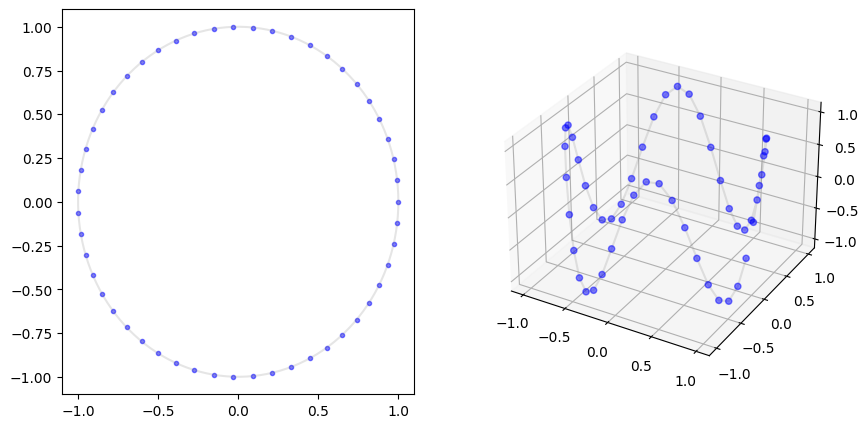

In [7]:
# plot dataset X_0

fig = plt.figure(figsize=(10, 5))

theta = np.linspace(0, 2 * np.pi, 150)
x = np.cos(theta)
y = np.sin(theta)

ax0 = fig.add_subplot(1, 2, 1)
ax0.plot(X_0[:, 0], X_0[:, 1], '.', color='blue', alpha = 0.5)
ax0.plot(x, y, alpha = 0.2, color = 'gray')

ax1 = fig.add_subplot(1, 2, 2, projection='3d')
ax1.scatter(X_0[:, 0], X_0[:, 1], Y_0, color='blue', alpha = 0.5)
ax1.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha = 0.2)

#fig.suptitle('Dataset X_0')
plt.show()

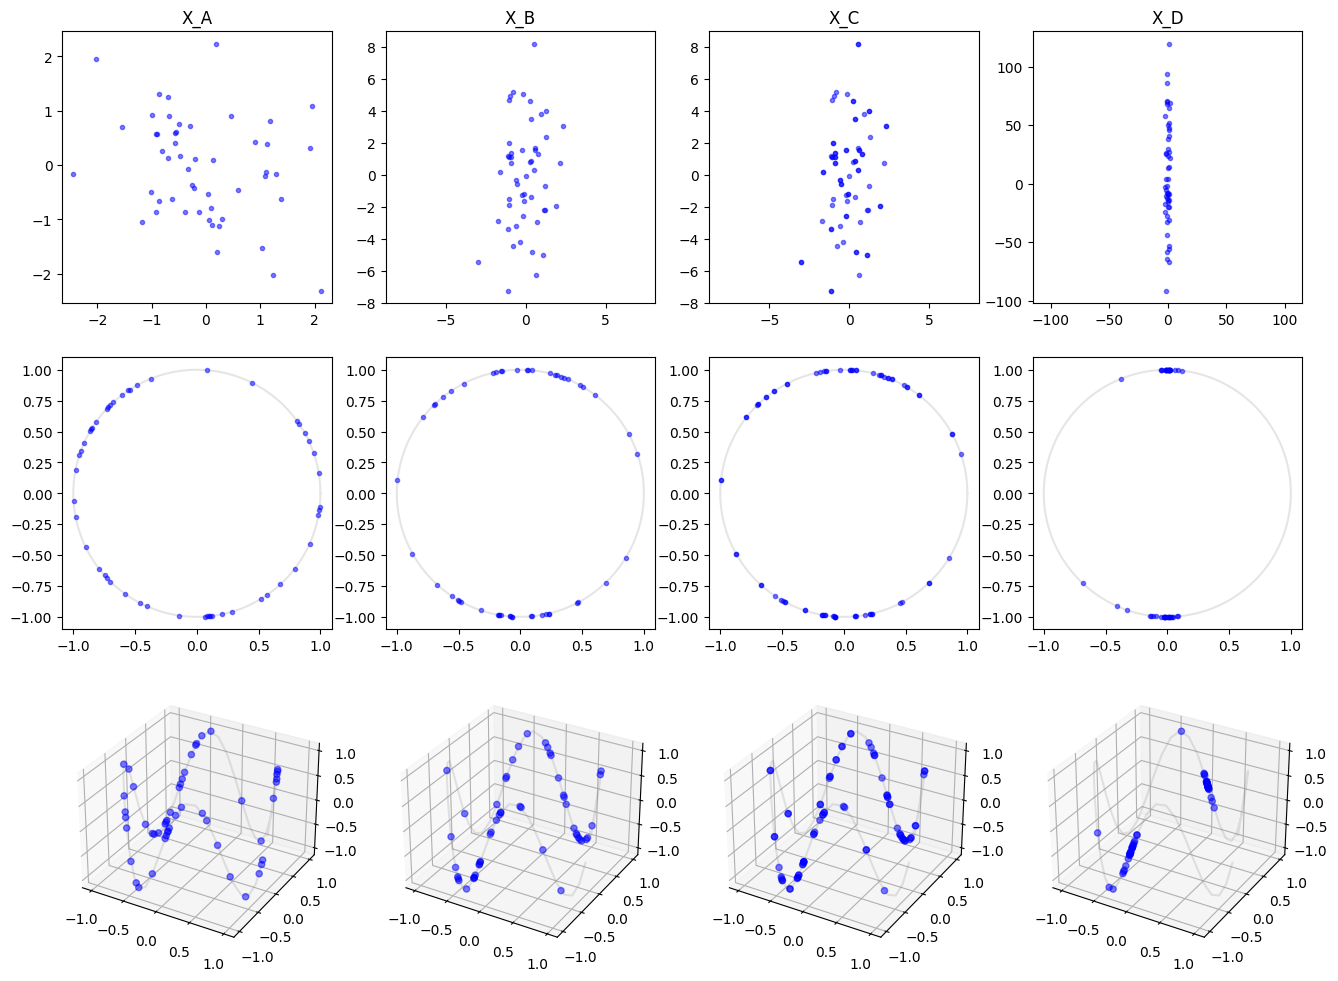

In [8]:
# plot datasets X_A, X_B, X_C, X_D

fig, axs = plt.subplots(3, 4, figsize=(16, 12))

# plot distribution of datapoints
axs[0][0].plot(X_A[:, 0], X_A[:, 1], '.', color='blue', alpha = 0.5)
axs[0][0].set_title('X_A')
axs[0][0].axis("equal")

axs[0][1].plot(X_B[:, 0], X_B[:, 1], '.', color='blue', alpha = 0.5)
axs[0][1].set_title('X_B')
axs[0][1].axis("equal")

axs[0][2].plot(X_C[:, 0], X_C[:, 1], '.', color='blue', alpha = 0.5)
axs[0][2].set_title('X_C')
axs[0][2].axis("equal")

axs[0][3].plot(X_D[:, 0], X_D[:, 1], '.', color='blue', alpha = 0.5)
axs[0][3].set_title('X_D')
axs[0][3].axis("equal")


# plot normalized data points
axs[1][0].plot(x, y, alpha = 0.2, color = 'gray')
axs[1][1].plot(x, y, alpha = 0.2, color = 'gray')
axs[1][2].plot(x, y, alpha = 0.2, color = 'gray')
axs[1][3].plot(x, y, alpha = 0.2, color = 'gray')

axs[1][0].plot(normX_A[:, 0], normX_A[:, 1], '.', color='blue', alpha = 0.5)
axs[1][0].set_xlim([-1, 1])
axs[1][0].axis("equal")

axs[1][1].plot(normX_B[:, 0], normX_B[:, 1], '.', color='blue', alpha = 0.5)
axs[1][1].set_ylim([-1, 1])
axs[1][1].axis("equal")

axs[1][2].plot(normX_C[:, 0], normX_C[:, 1], '.', color='blue', alpha = 0.5)
axs[1][2].set_xlim([-1, 1])
axs[1][2].axis("equal")

axs[1][3].plot(normX_D[:, 0], normX_D[:, 1], '.', color='blue', alpha = 0.5)
axs[1][3].set_xlim([-1, 1])
axs[1][3].axis("equal")

# plot 3D view
axs[2][0].remove()
axs[2][0] = fig.add_subplot(3, 4, 9, projection='3d')
axs[2][0].scatter(normX_A[:, 0], normX_A[:, 1], Y_A, color='blue', alpha=0.5)
axs[2][0].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

axs[2][1].remove()
axs[2][1] = fig.add_subplot(3, 4, 10, projection='3d')
axs[2][1].scatter(normX_B[:, 0], normX_B[:, 1], Y_B, color='blue', alpha=0.5)
axs[2][1].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

axs[2][2].remove()
axs[2][2] = fig.add_subplot(3, 4, 11, projection='3d')
axs[2][2].scatter(normX_C[:, 0], normX_C[:, 1], Y_C, color='blue', alpha=0.5)
axs[2][2].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

axs[2][3].remove()
axs[2][3] = fig.add_subplot(3, 4, 12, projection='3d')
axs[2][3].scatter(normX_D[:, 0], normX_D[:, 1], Y_D, color='blue', alpha=0.5)
axs[2][3].plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

plt.show()

## Gram matrix and its least eigenvalue

In [9]:
# compute the Gram matrix of a dataset X

def gram_matrix(X):
  H = torch.zeros((X.shape[0], X.shape[0]))

  for i in range(X.shape[0]):
    for j in range(i, X.shape[0]):
      rho = torch.clamp(torch.dot(X[i], X[j]), -1.0, 1.0) # ensures rho \in [-1, 1]
      H[i, j] = torch.clamp(torch.dot(X[i], X[j]), -1.0, 1.0)*(0.25 + (torch.arcsin(rho) / (2 * math.pi)))
      if i != j:
        H[j, i] = H[i, j]

  return H

In [10]:
# returns the least eigenvalue of a matrix H

def compute_lambda_min(H):
    eigenvalues = torch.linalg.eigvalsh(H)   # eigenvalues are returned in ascending order
    return eigenvalues[0]

In [11]:
H_0 = gram_matrix(X_0)
H_A = gram_matrix(normX_A)
H_B = gram_matrix(normX_B)
H_C = gram_matrix(normX_C)
H_D = gram_matrix(normX_D)

lambda_0 = compute_lambda_min(H_0)
lambda_A = compute_lambda_min(H_A)
lambda_B = compute_lambda_min(H_B)
lambda_C = compute_lambda_min(H_C)
lambda_D = compute_lambda_min(H_D)

print(lambda_0)
print(lambda_A)
print(lambda_B)
print(lambda_C)
print(lambda_D)

tensor(0.0049)
tensor(0.0004)
tensor(3.8061e-05)
tensor(-3.0556e-07)
tensor(-3.3417e-05)


In [12]:
def gram_matrix_of_k(X, W, a, m):
  H = torch.zeros(X.shape[0], X.shape[0])

  preActivation = X @ W # Shape (n, m)

  for i in range(X.shape[0]):
    for j in range(i, X.shape[0]):

      indicator = (preActivation[i, :] >= 0) & (preActivation[j, :] >= 0)

      H[i, j] = (1 / m) * torch.clamp(torch.dot(X[i], X[j]), -1.0, 1.0) * (torch.square(a) * indicator.float()).sum()

      if i != j:
        H[j, i] = H[i, j]

  return H

In [13]:
def norm(H):
  return torch.sum(H**2)

## Neural Network with one hidden layer and ReLU activation

In [14]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, d, m):
        super().__init__()
        self.W = torch.nn.Parameter(torch.randn(d, m, device=device))
        self.a = torch.nn.Parameter((-1)**torch.bernoulli(1/2 * torch.ones(m, device=device)))
        self.m = m

    def forward(self, X):
        Z = torch.relu(X @ self.W)
        U = (Z * self.a).sum(dim=1) / math.sqrt(self.m)
        return U

## Choice of Step Size

In [15]:
# m = 1000
# eta = [0.0001, 0.001, 0.01, 0.1, 1, 10]
# epochs = 20000

In [16]:
# # plots for dataset X_0

# plotY_0 = []

# for i in range(len(eta)):
#   plotX_0 = []

#   print(f"Training on dataset X_0 for eta = {eta[i]}")
#   model = NeuralNetwork(d, m)
#   optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])

#   for epoch in range(epochs):
#     optimizer.zero_grad()
#     U = model(X_0)
#     loss = 0.5 * torch.mean((U - Y_0) ** 2)
#     loss.backward()
#     optimizer.step()

#     if ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
#       print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
#       plotY_0.append(loss.item())
#       plotX_0.append(epoch+1)

In [17]:
# fig = plt.figure(figsize=(5,5))

# for i in range(len(eta)):

#   plt.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'eta = {eta[i]}')

# plt.title('X_0')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.show()

In [18]:
# # plots for dataset X_A

# plotY_A = []

# for i in range(len(eta)):
#   plotX_A = []

#   print(f"Training on dataset X_A for eta = {eta[i]}")
#   model = NeuralNetwork(d, m)
#   optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])

#   for epoch in range(epochs):
#     optimizer.zero_grad()
#     U = model(normX_A)
#     loss = 0.5 * torch.mean((U - Y_A) ** 2)
#     loss.backward()
#     optimizer.step()

#     if ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
#       print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
#       plotY_A.append(loss.item())
#       plotX_A.append(epoch+1)

In [19]:
# fig = plt.figure(figsize=(5,5))

# for i in range(len(eta)):

#   plt.loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = f'eta = {eta[i]}')

# plt.title('X_A')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.show()

In [20]:
# # plots for dataset X_B

# plotY_B = []

# for i in range(len(eta)):
#   plotX_B = []

#   print(f"Training on dataset X_B for eta = {eta[i]}")
#   model = NeuralNetwork(d, m)
#   optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])

#   for epoch in range(epochs):
#     optimizer.zero_grad()
#     U = model(normX_B)
#     loss = 0.5 * torch.mean((U - Y_B) ** 2)
#     loss.backward()
#     optimizer.step()

#     if ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
#       print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
#       plotY_B.append(loss.item())
#       plotX_B.append(epoch+1)

In [21]:
# fig = plt.figure(figsize=(5,5))

# for i in range(len(eta)):

#   plt.loglog(plotX_B, plotY_B[i*len(plotX_B):(i+1)*len(plotX_B)], label = f'eta = {eta[i]}')

# plt.title('X_B')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.show()

In [22]:
# # plots for dataset X_C

# plotY_C = []

# for i in range(len(eta)):
#   plotX_C = []

#   print(f"Training on dataset X_C for eta = {eta[i]}")
#   model = NeuralNetwork(d, m)
#   optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])

#   for epoch in range(epochs):
#     optimizer.zero_grad()
#     U = model(normX_C)
#     loss = 0.5 * torch.mean((U - Y_C) ** 2)
#     loss.backward()
#     optimizer.step()

#     if ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
#       print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
#       plotY_C.append(loss.item())
#       plotX_C.append(epoch+1)

In [23]:
# fig = plt.figure(figsize=(5,5))

# for i in range(len(eta)):

#   plt.loglog(plotX_C, plotY_C[i*len(plotX_C):(i+1)*len(plotX_C)], label = f'eta = {eta[i]}')

# plt.title('X_C')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.show()

In [24]:
# # plots for dataset X_D

# plotY_D = []

# for i in range(len(eta)):
#   plotX_D = []

#   print(f"Training on dataset X_D for eta = {eta[i]}")
#   model = NeuralNetwork(d, m)
#   optimizer = torch.optim.SGD([model.W, model.a], lr=eta[i])

#   for epoch in range(epochs):
#     optimizer.zero_grad()
#     U = model(normX_D)
#     loss = 0.5 * torch.mean((U - Y_D) ** 2)
#     loss.backward()
#     optimizer.step()

#     if ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
#       print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
#       plotY_D.append(loss.item())
#       plotX_D.append(epoch+1)

In [25]:
# fig = plt.figure(figsize=(5,5))

# for i in range(len(eta)):

#   plt.loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = f'eta = {eta[i]}')

# plt.title('X_D')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.show()

## Comparison for increasing network width

In [ ]:
m = [1, 10, 100, 1000, 10000, 100000]
eta = 1
epochs = 100 #20000

In [27]:
# grid_x = np.linspace(-1, 1, 50)
# grid_y = np.linspace(-1, 1, 50)
# X_grid, Y_grid = np.meshgrid(grid_x, grid_y)

# XY_grid = np.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)
# XY_grid = torch.tensor(XY_grid, dtype=torch.float32)

In [28]:
# plots for dataset X_0

plotY_0 = []
plotH_of_0 = []
plotH_diff = []

for i in range(len(m)):
  plotX_0 = []

  print(f"Training on dataset X_0 for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)
  W_0 = model.W.detach().clone()
  a_0 = model.a.detach().clone()
  H_of_0 = gram_matrix_of_k(X_0, W_0, a_0, m[i])
  plotH_of_0.append(norm(H_of_0 - H_0))

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(X_0)
    loss = 0.5 * torch.mean((U - Y_0) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_0.append(loss.item())
      plotX_0.append(epoch+1)

      H_of_k = gram_matrix_of_k(X_0, model.W, model.a, m[i])
      plotH_diff.append(norm(H_of_k - H_of_0).item())
      print('||H(k)-H(0)||', norm(H_of_k - H_of_0).item())

      '''if (epoch+1 == 20000): #(epoch == 0) | (epoch+1 == 100) | (epoch+1 == 1000) | (epoch+1 == 20000):
        W = model(XY_grid)

        fig = plt.figure(figsize=(12,10))

        ax = fig.add_subplot(121, projection='3d')
        ax.scatter(X_0[:, 0], X_0[:, 1], Y_0, color='red', alpha = 0.5)
        ax.scatter(X_0[:, 0], X_0[:, 1], U.detach().numpy(), color='blue', alpha = 0.5)
        ax.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        ax2.scatter(X_0[:, 0], X_0[:, 1], Y_0, color='red', alpha = 0.5)
        ax2.plot_wireframe(X_grid, Y_grid, W.reshape(X_grid.shape).detach().numpy(), color='blue', alpha = 0.5)

        plt.show()'''

    loss.backward()
    optimizer.step()

Training on dataset X_0 for m = 1
Epoch 1 Loss: 0.6744368076
||H(k)-H(0)|| 0.0
Epoch 2 Loss: 0.2504217923
||H(k)-H(0)|| 304.00311279296875
Epoch 3 Loss: 0.2495185882
||H(k)-H(0)|| 308.31689453125
Epoch 4 Loss: 0.249319464
||H(k)-H(0)|| 309.8191223144531
Epoch 5 Loss: 0.2492724657
||H(k)-H(0)|| 310.4088439941406
Epoch 6 Loss: 0.2492589206
||H(k)-H(0)|| 310.6572265625
Epoch 7 Loss: 0.2492528111
||H(k)-H(0)|| 310.7640380859375
Epoch 8 Loss: 0.249248296
||H(k)-H(0)|| 310.8082580566406
Epoch 9 Loss: 0.2492441237
||H(k)-H(0)|| 310.8238525390625
Epoch 10 Loss: 0.2492400408
||H(k)-H(0)|| 310.82611083984375
Epoch 20 Loss: 0.2491984963
||H(k)-H(0)|| 310.7389221191406
Epoch 30 Loss: 0.2491818815
||H(k)-H(0)|| 310.83148193359375
Epoch 40 Loss: 0.2491710186
||H(k)-H(0)|| 310.80767822265625
Epoch 50 Loss: 0.2491601855
||H(k)-H(0)|| 310.7839660644531
Epoch 60 Loss: 0.2491494119
||H(k)-H(0)|| 310.76031494140625
Epoch 70 Loss: 0.2491386086
||H(k)-H(0)|| 310.7366943359375
Epoch 80 Loss: 0.2491278946
||H

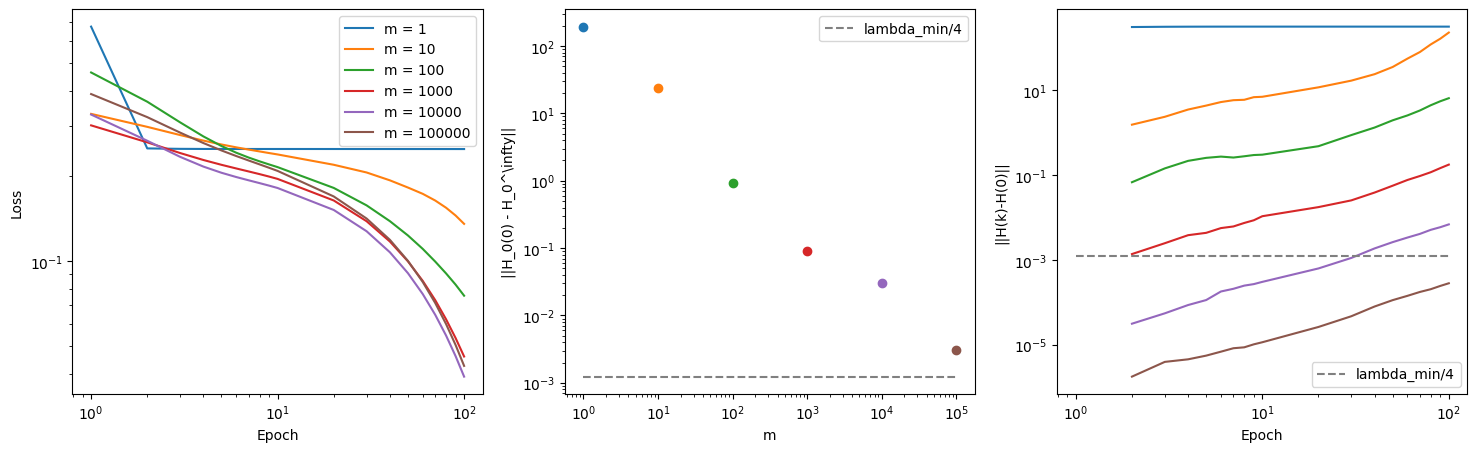

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(len(m)):
  ax[0].loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = f'm = {m[i]}')
  ax[2].loglog(plotX_0[1::], plotH_diff[i*len(plotX_0)+1:(i+1)*len(plotX_0)], '-')
  ax[1].loglog(m[i], plotH_of_0[i], 'o')

ax[2].loglog(plotX_0, torch.full((len(plotX_0),), (lambda_0/4).item()), '--', label = 'lambda_min/4', color = 'gray')
ax[1].loglog(m, torch.full((len(m),), (lambda_0/4).item()), '--', label = 'lambda_min/4', color = 'gray')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('||H(k)-H(0)||')
ax[2].legend()

ax[1].set_xlabel('m')
ax[1].set_ylabel(r'||H_0(0) - H_0^\infty||')
ax[1].legend()

plt.show()

In [30]:
# plots for dataset X_A

plotY_A = []
plotH_A_of_0 = []
plotH_A_diff = []

for i in range(len(m)):
  plotX_A = []

  print(f"Training on dataset X_A for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)
  W_A = model.W.detach().clone()
  a_A = model.a.detach().clone()
  H_A_of_0 = gram_matrix_of_k(normX_A, W_A, a_A, m[i])
  plotH_A_of_0.append(norm(H_A_of_0 - H_A))

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_A)
    loss = 0.5 * torch.mean((U - Y_A) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_A.append(loss.item())
      plotX_A.append(epoch+1)

      H_A_of_k = gram_matrix_of_k(normX_A, model.W, model.a, m[i])
      plotH_A_diff.append(norm(H_A_of_k - H_A_of_0).item())
      print('||H_A(k)-H_A(0)||', norm(H_A_of_k - H_A_of_0).item())

      '''      if (epoch+1 == 20000):
        W = model(XY_grid)

        fig = plt.figure(figsize=(12,10))

        ax = fig.add_subplot(121, projection='3d')
        ax.scatter(normX_A[:, 0], normX_A[:, 1], Y_A, color='red', alpha = 0.5)
        ax.scatter(normX_A[:, 0], normX_A[:, 1], U.detach().numpy(), color='blue', alpha = 0.5)
        ax.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        ax2.scatter(normX_A[:, 0], normX_A[:, 1], Y_A, color='red', alpha = 0.5)
        ax2.plot_wireframe(X_grid, Y_grid, W.reshape(X_grid.shape).detach().numpy(), color='blue', alpha = 0.5)

        plt.show()'''

    loss.backward()
    optimizer.step()

Training on dataset X_A for m = 1
Epoch 1 Loss: 0.3319351673
||H_A(k)-H_A(0)|| 0.0
Epoch 2 Loss: 0.233452782
||H_A(k)-H_A(0)|| 158.53628540039062
Epoch 3 Loss: 0.2207580954
||H_A(k)-H_A(0)|| 211.0096893310547
Epoch 4 Loss: 0.2162829787
||H_A(k)-H_A(0)|| 263.6014709472656
Epoch 5 Loss: 0.2147093415
||H_A(k)-H_A(0)|| 281.6434631347656
Epoch 6 Loss: 0.2139084339
||H_A(k)-H_A(0)|| 294.3126525878906
Epoch 7 Loss: 0.2134782374
||H_A(k)-H_A(0)|| 303.36553955078125
Epoch 8 Loss: 0.2132371664
||H_A(k)-H_A(0)|| 309.9231872558594
Epoch 9 Loss: 0.2130966783
||H_A(k)-H_A(0)|| 314.72247314453125
Epoch 10 Loss: 0.213011533
||H_A(k)-H_A(0)|| 318.2613830566406
Epoch 20 Loss: 0.2128236741
||H_A(k)-H_A(0)|| 327.9849548339844
Epoch 30 Loss: 0.2127927095
||H_A(k)-H_A(0)|| 328.39300537109375
Epoch 40 Loss: 0.2127834558
||H_A(k)-H_A(0)|| 328.36767578125
Epoch 50 Loss: 0.2127806693
||H_A(k)-H_A(0)|| 328.36004638671875
Epoch 60 Loss: 0.2127798796
||H_A(k)-H_A(0)|| 328.3633728027344
Epoch 70 Loss: 0.2127795815


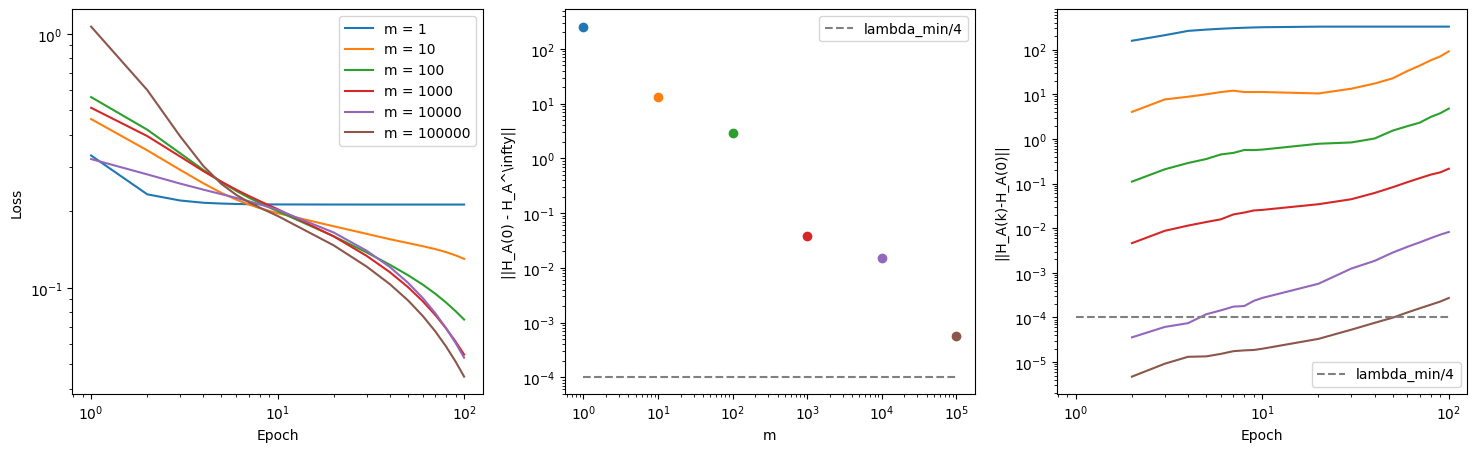

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(len(m)):
  ax[0].loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = f'm = {m[i]}')
  ax[2].loglog(plotX_A[1::], plotH_A_diff[i*len(plotX_A)+1:(i+1)*len(plotX_A)])
  ax[1].loglog(m[i], plotH_A_of_0[i], 'o')

ax[2].loglog(plotX_A, torch.full((len(plotX_A),), (lambda_A/4).item()), '--', label = 'lambda_min/4', color = 'gray')
ax[1].loglog(m, torch.full((len(m),), (lambda_A/4).item()), '--', label = 'lambda_min/4', color = 'gray')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('||H_A(k)-H_A(0)||')
ax[2].legend()

ax[1].set_xlabel('m')
ax[1].set_ylabel('||H_A(0) - H_A^\infty||')
ax[1].legend()

plt.show()

In [32]:
# plots for dataset X_B

plotY_B = []
plotH_B_of_0 = []
plotH_B_diff = []

for i in range(len(m)):
  plotX_B = []

  print(f"Training on dataset X_B for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)
  W_B = model.W.detach().clone()
  a_B = model.a.detach().clone()
  H_B_of_0 = gram_matrix_of_k(normX_B, W_B, a_B, m[i])
  plotH_B_of_0.append(norm(H_B_of_0 - H_B))

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_B)
    loss = 0.5 * torch.mean((U - Y_B) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_B.append(loss.item())
      plotX_B.append(epoch+1)

      H_B_of_k = gram_matrix_of_k(normX_B, model.W, model.a, m[i])
      plotH_B_diff.append(norm(H_B_of_k - H_B_of_0).item())
      print('||H_B(k)-H_B(0)||', norm(H_B_of_k - H_B_of_0).item())

      '''      if (epoch+1 == 20000):
        W = model(XY_grid)

        fig = plt.figure(figsize=(12,10))

        ax = fig.add_subplot(121, projection='3d')
        ax.scatter(normX_B[:, 0], normX_B[:, 1], Y_B, color='red', alpha = 0.5)
        ax.scatter(normX_B[:, 0], normX_B[:, 1], U.detach().numpy(), color='blue', alpha = 0.5)
        ax.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        ax2.scatter(normX_B[:, 0], normX_B[:, 1], Y_B, color='red', alpha = 0.5)
        ax2.plot_wireframe(X_grid, Y_grid, W.reshape(X_grid.shape).detach().numpy(), color='blue', alpha = 0.5)

        plt.show()'''

    loss.backward()
    optimizer.step()

Training on dataset X_B for m = 1
Epoch 1 Loss: 0.3209281564
||H_B(k)-H_B(0)|| 0.0
Epoch 2 Loss: 0.2557446361
||H_B(k)-H_B(0)|| 244.45127868652344
Epoch 3 Loss: 0.2250715196
||H_B(k)-H_B(0)|| 374.06390380859375
Epoch 4 Loss: 0.2234078944
||H_B(k)-H_B(0)|| 360.98162841796875
Epoch 5 Loss: 0.2223180383
||H_B(k)-H_B(0)|| 351.1150817871094
Epoch 6 Loss: 0.2215668708
||H_B(k)-H_B(0)|| 343.39190673828125
Epoch 7 Loss: 0.2210294455
||H_B(k)-H_B(0)|| 337.1911926269531
Epoch 8 Loss: 0.2206339687
||H_B(k)-H_B(0)|| 332.120361328125
Epoch 9 Loss: 0.2203365415
||H_B(k)-H_B(0)|| 327.91436767578125
Epoch 10 Loss: 0.2201088965
||H_B(k)-H_B(0)|| 324.3856201171875
Epoch 20 Loss: 0.2195159942
||H_B(k)-H_B(0)|| 321.74981689453125
Epoch 30 Loss: 0.2195828259
||H_B(k)-H_B(0)|| 305.8994445800781
Epoch 40 Loss: 0.2194719911
||H_B(k)-H_B(0)|| 305.24114990234375
Epoch 50 Loss: 0.2194778025
||H_B(k)-H_B(0)|| 305.0208740234375
Epoch 60 Loss: 0.2194866985
||H_B(k)-H_B(0)|| 304.8209533691406
Epoch 70 Loss: 0.219503

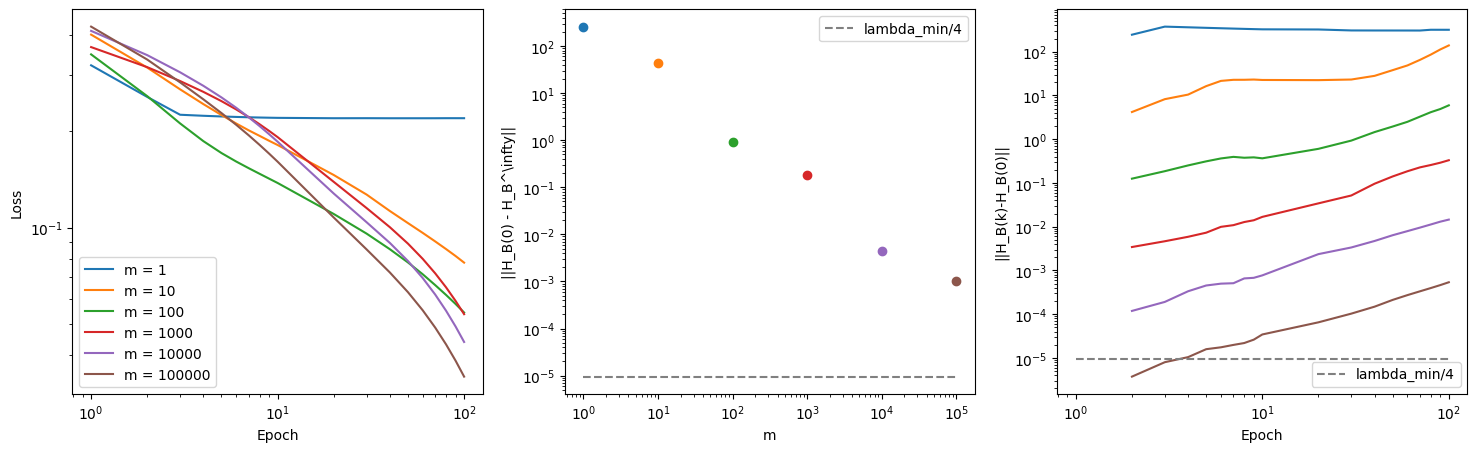

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(len(m)):
  ax[0].loglog(plotX_B, plotY_B[i*len(plotX_B):(i+1)*len(plotX_B)], label = f'm = {m[i]}')
  ax[2].loglog(plotX_B[1::], plotH_B_diff[i*len(plotX_B)+1:(i+1)*len(plotX_B)])
  ax[1].loglog(m[i], plotH_B_of_0[i], 'o')
  
ax[2].loglog(plotX_B, torch.full((len(plotX_B),), (lambda_B/4).item()), '--', label = 'lambda_min/4', color = 'gray')
ax[1].loglog(m, torch.full((len(m),), (lambda_B/4).item()), '--', label = 'lambda_min/4', color = 'gray')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('||H_B(k)-H_B(0)||')
ax[2].legend()

ax[1].set_xlabel('m')
ax[1].set_ylabel('||H_B(0) - H_B^\infty||')
ax[1].legend()

plt.show()

In [34]:
# plots for dataset X_C

plotY_C = []
plotH_C_of_0 = []
plotH_C_diff = []

for i in range(len(m)):
  plotX_C = []

  print(f"Training on dataset X_C for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)
  W_C = model.W.detach().clone()
  a_C = model.a.detach().clone()
  H_C_of_0 = gram_matrix_of_k(normX_C, W_C, a_C, m[i])
  plotH_C_of_0.append(norm(H_C_of_0 - H_C))

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_C)
    loss = 0.5 * torch.mean((U - Y_C) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_C.append(loss.item())
      plotX_C.append(epoch+1)

      H_C_of_k = gram_matrix_of_k(normX_C, model.W, model.a, m[i])
      plotH_C_diff.append(norm(H_C_of_k - H_C_of_0).item())
      print('||H_C(k)-H_C(0)||', norm(H_C_of_k - H_C_of_0).item())

      '''      if (epoch+1 == 20000):
        W = model(XY_grid)

        fig = plt.figure(figsize=(12,10))

        ax = fig.add_subplot(121, projection='3d')
        ax.scatter(normX_C[:, 0], normX_C[:, 1], Y_C, color='red', alpha = 0.5)
        ax.scatter(normX_C[:, 0], normX_C[:, 1], U.detach().numpy(), color='blue', alpha = 0.5)
        ax.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        ax2.scatter(normX_C[:, 0], normX_C[:, 1], Y_C, color='red', alpha = 0.5)
        ax2.plot_wireframe(X_grid, Y_grid, W.reshape(X_grid.shape).detach().numpy(), color='blue', alpha = 0.5)

        plt.show()'''

    loss.backward()
    optimizer.step()

Training on dataset X_C for m = 1
Epoch 1 Loss: 0.2588827014
||H_C(k)-H_C(0)|| 0.0
Epoch 2 Loss: 0.221998632
||H_C(k)-H_C(0)|| 448.8648986816406
Epoch 3 Loss: 0.2212723345
||H_C(k)-H_C(0)|| 441.0189514160156
Epoch 4 Loss: 0.2210925967
||H_C(k)-H_C(0)|| 512.2032470703125
Epoch 5 Loss: 0.2208330929
||H_C(k)-H_C(0)|| 431.9486083984375
Epoch 6 Loss: 0.2206192762
||H_C(k)-H_C(0)|| 500.0094909667969
Epoch 7 Loss: 0.2205899507
||H_C(k)-H_C(0)|| 426.3817443847656
Epoch 8 Loss: 0.2203953266
||H_C(k)-H_C(0)|| 424.28033447265625
Epoch 9 Loss: 0.220336169
||H_C(k)-H_C(0)|| 488.80792236328125
Epoch 10 Loss: 0.2203489989
||H_C(k)-H_C(0)|| 421.6036682128906
Epoch 20 Loss: 0.2202559114
||H_C(k)-H_C(0)|| 474.5118408203125
Epoch 30 Loss: 0.2200641185
||H_C(k)-H_C(0)|| 415.3980712890625
Epoch 40 Loss: 0.220081225
||H_C(k)-H_C(0)|| 415.11334228515625
Epoch 50 Loss: 0.2201885432
||H_C(k)-H_C(0)|| 364.77020263671875
Epoch 60 Loss: 0.2200416476
||H_C(k)-H_C(0)|| 414.8857727050781
Epoch 70 Loss: 0.2200436741


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


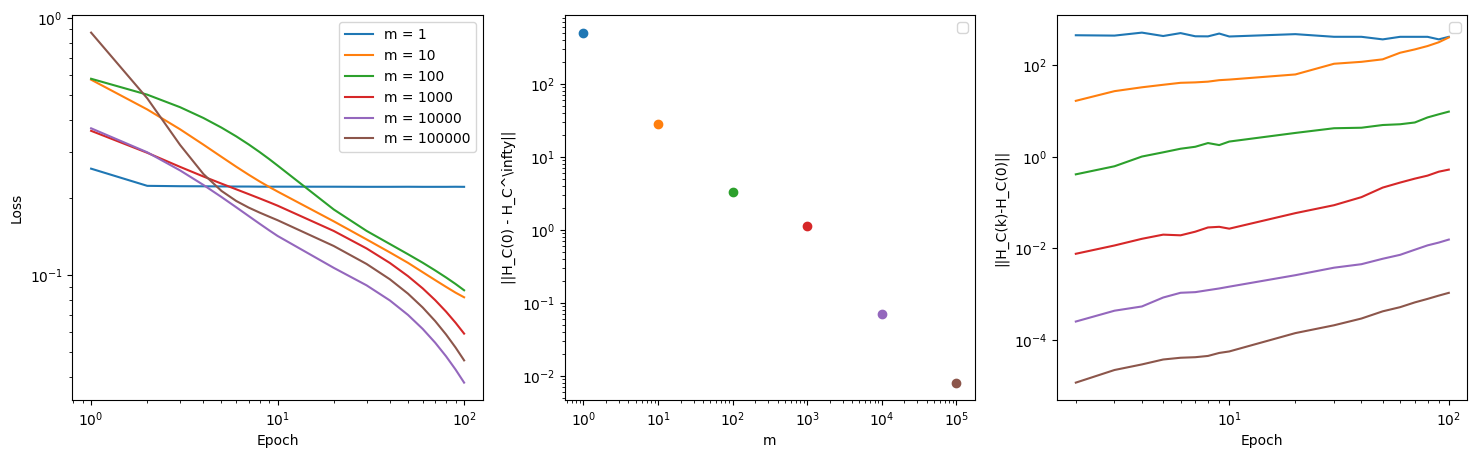

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(len(m)):
  ax[0].loglog(plotX_C, plotY_C[i*len(plotX_C):(i+1)*len(plotX_C)], label = f'm = {m[i]}')
  ax[2].loglog(plotX_C[1::], plotH_C_diff[i*len(plotX_C)+1:(i+1)*len(plotX_C)])
  ax[1].loglog(m[i], plotH_C_of_0[i], 'o')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('||H_C(k)-H_C(0)||')
ax[2].legend()

ax[1].set_xlabel('m')
ax[1].set_ylabel('||H_C(0) - H_C^\infty||')
ax[1].legend()

plt.show()

In [36]:
# plots for dataset X_D

plotY_D = []
plotH_D_of_0 = []
plotH_D_diff = []

for i in range(len(m)):
  plotX_D = []

  print(f"Training on dataset X_D for m = {m[i]}")
  model = NeuralNetwork(d, m[i])
  optimizer = torch.optim.SGD([model.W, model.a], lr=eta)
  W_D = model.W.detach().clone()
  a_D = model.a.detach().clone()
  H_D_of_0 = gram_matrix_of_k(normX_D, W_D, a_D, m[i])
  plotH_D_of_0.append(norm(H_D_of_0 - H_D))

  for epoch in range(epochs):
    optimizer.zero_grad()
    U = model(normX_D)
    loss = 0.5 * torch.mean((U - Y_D) ** 2)

    if (epoch < 10) | ((epoch < 100) & ((epoch+1) % 10 == 0)) | ((epoch < 1000) & ((epoch+1) % 100 == 0)) | (epoch == 0) | ((epoch < 10000) & ((epoch+1) % 1000 == 0)) | ((epoch+1) % 10000 == 0):
      print('Epoch', epoch+1, 'Loss:', np.round(loss.item(), decimals=10))
      plotY_D.append(loss.item())
      plotX_D.append(epoch+1)

      H_D_of_k = gram_matrix_of_k(normX_D, model.W, model.a, m[i])
      plotH_D_diff.append(norm(H_D_of_k - H_D_of_0).item())
      print('||H_D(k)-H_D(0)||', norm(H_D_of_k - H_D_of_0).item())

      '''if (epoch+1 == 20000):
        W = model(XY_grid)

        fig = plt.figure(figsize=(12,10))

        ax = fig.add_subplot(121, projection='3d')
        ax.scatter(normX_D[:, 0], normX_D[:, 1], Y_D, color='red', alpha = 0.5)
        ax.scatter(normX_D[:, 0], normX_D[:, 1], U.detach().numpy(), color='blue', alpha = 0.5)
        ax.plot(X_0[:, 0], X_0[:, 1], Y_0, color='gray', alpha=0.2)

        ax2 = fig.add_subplot(1, 2, 2, projection='3d')
        ax2.scatter(normX_D[:, 0], normX_D[:, 1], Y_D, color='red', alpha = 0.5)
        ax2.plot_wireframe(X_grid, Y_grid, W.reshape(X_grid.shape).detach().numpy(), color='blue', alpha = 0.5)

        plt.show()'''

    loss.backward()
    optimizer.step()

Training on dataset X_D for m = 1
Epoch 1 Loss: 0.0410312898
||H_D(k)-H_D(0)|| 0.0
Epoch 2 Loss: 0.040389251
||H_D(k)-H_D(0)|| 0.010700671933591366
Epoch 3 Loss: 0.0400278606
||H_D(k)-H_D(0)|| 0.007239175494760275
Epoch 4 Loss: 0.0397377051
||H_D(k)-H_D(0)|| 0.00010599360393825918
Epoch 5 Loss: 0.0394690596
||H_D(k)-H_D(0)|| 0.009204589761793613
Epoch 6 Loss: 0.0392095335
||H_D(k)-H_D(0)|| 0.049601659178733826
Epoch 7 Loss: 0.0389559306
||H_D(k)-H_D(0)|| 0.13306307792663574
Epoch 8 Loss: 0.0387073159
||H_D(k)-H_D(0)|| 0.2697717845439911
Epoch 9 Loss: 0.0384633616
||H_D(k)-H_D(0)|| 0.4692828953266144
Epoch 10 Loss: 0.038223885
||H_D(k)-H_D(0)|| 0.7408812642097473
Epoch 20 Loss: 0.0371626094
||H_D(k)-H_D(0)|| 56.557804107666016
Epoch 30 Loss: 0.0369283631
||H_D(k)-H_D(0)|| 64.3073501586914
Epoch 40 Loss: 0.0367727317
||H_D(k)-H_D(0)|| 72.48393249511719
Epoch 50 Loss: 0.0366722569
||H_D(k)-H_D(0)|| 80.49114227294922
Epoch 60 Loss: 0.0366090797
||H_D(k)-H_D(0)|| 87.85759735107422
Epoch 70 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


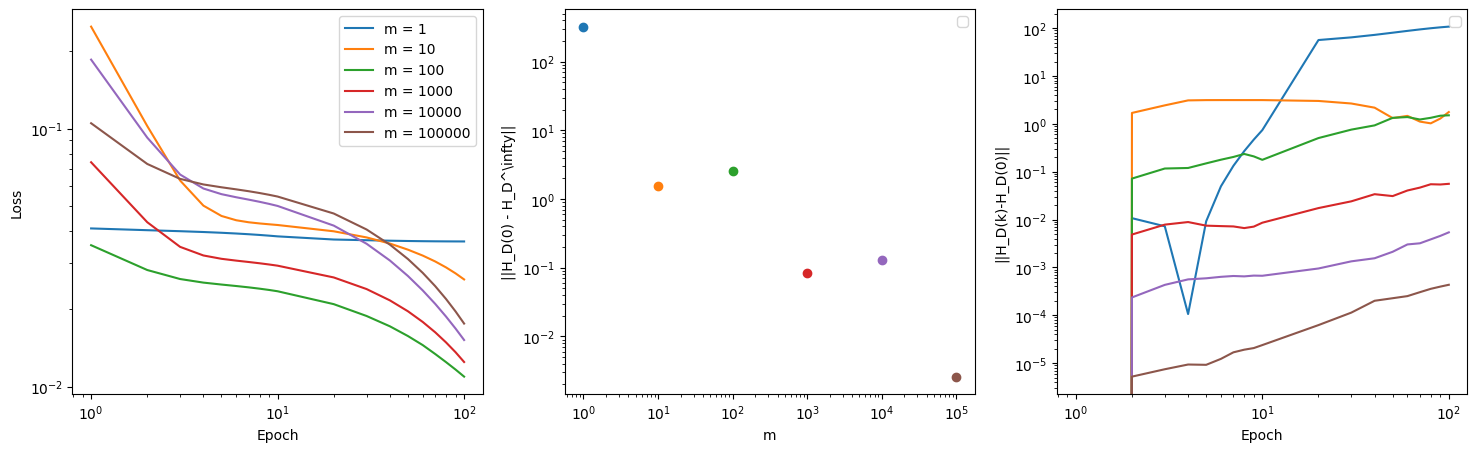

In [37]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i in range(len(m)):
  ax[0].loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = f'm = {m[i]}')
  ax[2].loglog(plotX_D, plotH_D_diff[i*len(plotX_D):(i+1)*len(plotX_D)])
  ax[1].loglog(m[i], plotH_D_of_0[i], 'o')

#ax[1].loglog(plotX_D, torch.full((len(plotX_D),), (lambda_D/4).item()), '--', label = 'theoretical bound', color = 'gray')
#ax[2].loglog(m, torch.full((len(m),), (lambda_D/4).item()), '--', label = 'theoretical bound', color = 'gray')

ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('||H_D(k)-H_D(0)||')
ax[2].legend()

ax[1].set_xlabel('m')
ax[1].set_ylabel('||H_D(0) - H_D^\infty||')
ax[1].legend()

plt.show()

## Comparison of Convergence for different datasets

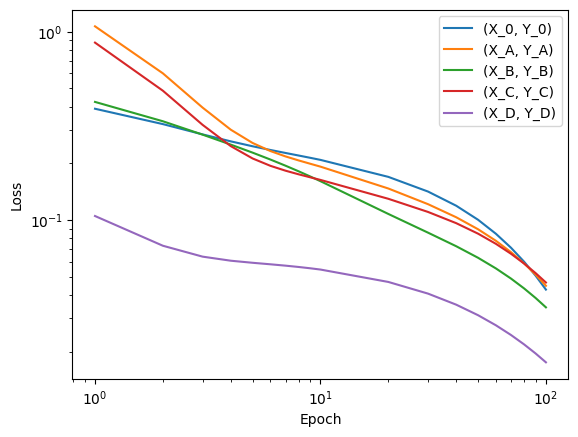

In [38]:
i = len(m) - 1

plt.loglog(plotX_0, plotY_0[i*len(plotX_0):(i+1)*len(plotX_0)], label = '(X_0, Y_0)', color = 'tab:blue')
#plt.loglog(plotX_0, (1 - (eta*lambda_0*0.5))**torch.tensor(plotX_0) * plotY_0[0], '--', color = 'blue')
plt.loglog(plotX_A, plotY_A[i*len(plotX_A):(i+1)*len(plotX_A)], label = '(X_A, Y_A)', color = 'tab:orange')
#plt.loglog(plotX_0, (1 - (eta*lambda_A*0.5))**torch.tensor(plotX_0) * plotY_A[0], '--', color = 'red')
plt.loglog(plotX_B, plotY_B[i*len(plotX_B):(i+1)*len(plotX_B)], label = '(X_B, Y_B)', color = 'tab:green')
plt.loglog(plotX_C, plotY_C[i*len(plotX_C):(i+1)*len(plotX_C)], label = '(X_C, Y_C)', color = 'tab:red')
plt.loglog(plotX_D, plotY_D[i*len(plotX_D):(i+1)*len(plotX_D)], label = '(X_D, Y_D)', color = 'tab:purple')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()